In [2]:
import scanpy as sc
import anndata as ad
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
import matplotlib as mp
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

In [3]:
# load matrix
X = io.mmread("nathanson.counts.mtx")

# create anndata object
adata = ad.AnnData(
    X=X.transpose().tocsr()
)

# load metadata
cell_meta = pd.read_csv("nathanson.metadata.csv", low_memory=False)

# load gene names
with open("nathanson.gene.names.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

In [4]:
adata

AnnData object with n_obs × n_vars = 51 × 35479
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Group', 'Receptor', 'Mutation', 'Primary_Recurrent', 'Treatment', 'batch', 'final_subtype', 'wap_cre_deg_all_cells1', 'subtype_M_or_other', 'blg_cre_deg_all_cells1', 'blg_cre_deg1', 'misc', 'mouse_blg_like', 'subtype_mutation', 'subtype_mutation_other', 'wap_cre_deg1', 'tcga1', 'barcode'

In [11]:
adata.obs.index.to_list()

['Brca1Br169_kallisto',
 'Brca1Br170_kallisto',
 'Brca1Br121_kallisto',
 'Brca1Br122_kallisto',
 'Brca1Br142_kallisto',
 'Brca1Br28_kallisto',
 'Brca1Br123_kallisto',
 'Brca1Br125_kallisto',
 'Brca1Br128_kallisto',
 'Brca1Br29_kallisto',
 'Brca1Br126_kallisto',
 'Brca1Br159_kallisto',
 'Brca1Br168_kallisto',
 'Brca2Br84_kallisto',
 'Brca1Br44_kallisto',
 'TNBC_BRCA1_15',
 'TNBC_BRCA1_16',
 'TNBC_BRCA1_17',
 'TNBC_BRCA1_18',
 'TNBC_BRCA1_19',
 'TNBC_BRCA1_20',
 'TNBC_BRCA1_21',
 'TNBC_BRCA1_22',
 'TNBC_BRCA1_23',
 'TNBC_BRCA1_24',
 'TNBC_BRCA1_25',
 'TNBC_BRCA1_26',
 'TNBC_BRCA1_27',
 'TNBC_BRCA1_28',
 'TNBC_BRCA1_29',
 'TNBC_BRCA1_30',
 'TNBC_BRCA1_31',
 'TNBC_BRCA1_33',
 'TNBC_BRCA1_34',
 'TNBC_BRCA1_35',
 'TNBC_WT_36',
 'TNBC_WT_37',
 'TNBC_WT_38',
 'TNBC_WT_39',
 'TNBC_WT_40',
 'TNBC_WT_41',
 'TNBC_WT_42',
 'TNBC_WT_43',
 'TNBC_WT_44',
 'TNBC_WT_45',
 'TNBC_WT_46',
 'TNBC_WT_47',
 'TNBC_WT_48',
 'TNBC_WT_49',
 'TNBC_WT_50',
 'TNBC_WT_52']

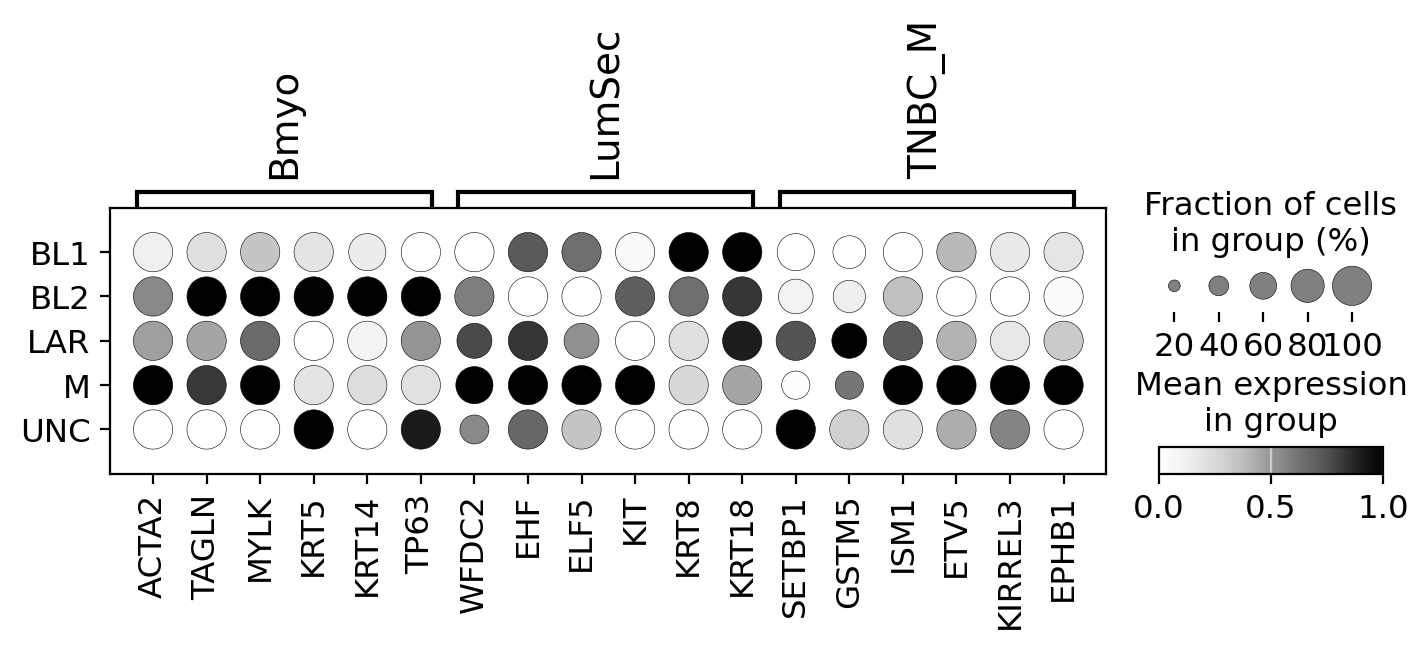

In [21]:
marker_genes = {
    "Bmyo": ["ACTA2","TAGLN","MYLK","KRT5","KRT14","TP63"],
    "LumSec": ["WFDC2","EHF","ELF5","KIT","KRT8","KRT18"],
    "TNBC_M":["SETBP1","GSTM5","ISM1","ETV5","KIRREL3","EPHB1"]}


sc.pl.dotplot(adata, marker_genes, groupby="final_subtype",standard_scale="var",swap_axes=False,cmap='Greys')#,save='_tcga_mesenchymal_canonical.pdf')

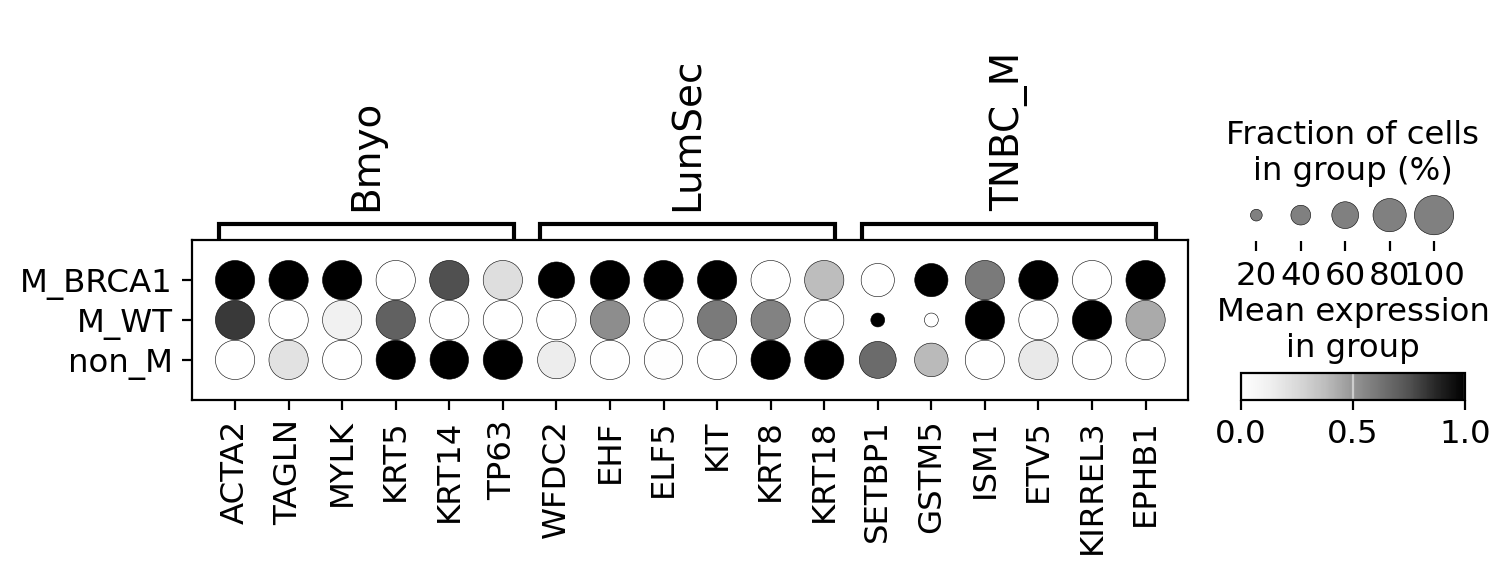

In [23]:
marker_genes = {
    "Bmyo": ["ACTA2","TAGLN","MYLK","KRT5","KRT14","TP63"],
    "LumSec": ["WFDC2","EHF","ELF5","KIT","KRT8","KRT18"],
    "TNBC_M":["SETBP1","GSTM5","ISM1","ETV5","KIRREL3","EPHB1"]}


sc.pl.dotplot(adata, marker_genes, groupby="subtype_mutation_other",standard_scale="var",swap_axes=False,cmap='Greys',save='_nathanson_mesenchymal_canonical.pdf')

In [56]:
adata.write('final_brca1_wt_tumors.h5ad')

In [3]:
adata=sc.read_h5ad('final_brca1_wt_tumors.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 51 × 35479
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Group', 'Receptor', 'Mutation', 'Primary_Recurrent', 'Treatment', 'batch', 'final_subtype', 'wap_cre_deg_all_cells1', 'subtype_M_or_other', 'blg_cre_deg_all_cells1', 'blg_cre_deg1', 'misc', 'mouse_blg_like', 'subtype_mutation', 'subtype_mutation_other', 'wap_cre_deg1', 'tcga1', 'barcode'

In [5]:
blg=pd.read_csv("as_human_blg_sig_degs_aneuploid_tumor_vs_normal_sampled_epi_wilcox.csv",index_col=1)
wap=pd.read_csv("as_human_wap_sig_degs_aneuploid_tumor_vs_normal_sampled_epi_wilcox.csv",index_col=1)
tnbc_m=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/TCGA/tcga_mesenchymal_genes_as_human.csv",index_col=0)

In [6]:
blg=blg.index.to_list()
wap=wap.index.to_list()
tnbc_m=tnbc_m.index.to_list()

In [7]:
sc.tl.score_genes(adata, blg,
                  gene_pool=None, n_bins=50, score_name='blg', 
                  random_state=0, copy=False, use_raw=None)

sc.tl.score_genes(adata, wap,
                  gene_pool=None, n_bins=50, score_name='wap', 
                  random_state=0, copy=False, use_raw=None)

sc.tl.score_genes(adata, tnbc_m,
                  gene_pool=None, n_bins=50, score_name='tcga_M', 
                  random_state=0, copy=False, use_raw=None)

       'IFI27L2A', 'APOL9B', 'WFDC18',
       ...
       'GM38037', 'PMEPA1OS', '4930427A07RIK', 'GM19412', 'CCL6',
       '4930532G15RIK', 'GM26641', 'PHF11B', '4632415L05RIK', 'F830016B08RIK'],
      dtype='object', length=165)
       'C16ORF74', 'C1ORF53', 'C21ORF91',
       ...
       'HASPIN', 'AI838599', 'MINAR2', 'SLC36A3OS', '6330403L08RIK', 'GM38251',
       'GM29010', 'CNMD', 'INSYN1', 'GM47405'],
      dtype='object', length=169)
       'LOC284009', 'C7orf52', 'FAM154B', 'GATSL1',
       ...
       'C2orf63', 'C6orf134', 'LPPR2', 'C20orf112', 'ACCN2', 'C12orf53',
       'GEFT', 'C20orf117', 'C1orf133', 'SEPT5'],
      dtype='object', length=123)


/tmp/ipykernel_1654178/1306314796.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='subtype_mutation_other', y='blg_cre_deg1', data=df,


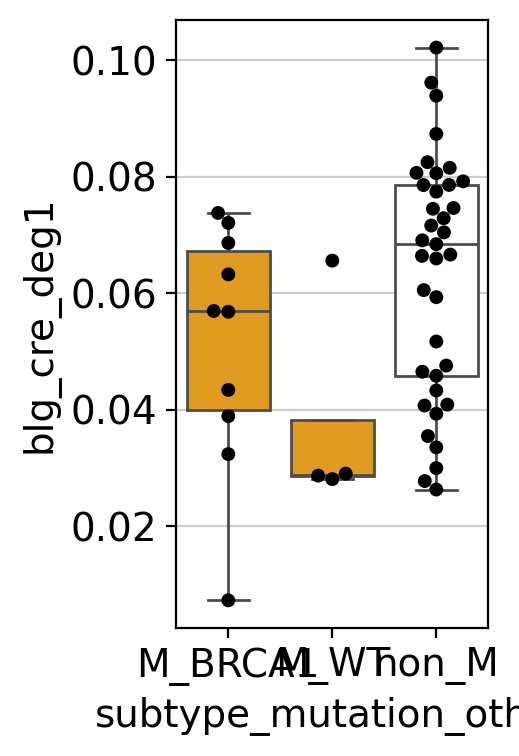

In [70]:
fig, ax = plt.subplots(figsize=(2, 4))

df=adata.obs

ax = sns.boxplot(x='subtype_mutation_other', y='blg_cre_deg1', data=df, 
                 showfliers=False,palette=['orange','orange','white']) # Hide default outliers

# 3. Overlay the swarm plot (or stripplot) to show colored points
# The 'hue' argument automatically colors points by category
sns.swarmplot(x='subtype_mutation_other', y='blg_cre_deg1', data=df, hue='subtype_mutation_other', ax=ax, 
              palette=['black','black','black'], marker='o', s=5)
        
plt.savefig('fig2_blg_barplots.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1654178/2729310226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='subtype_mutation_other', y='wap_cre_deg1', data=df,


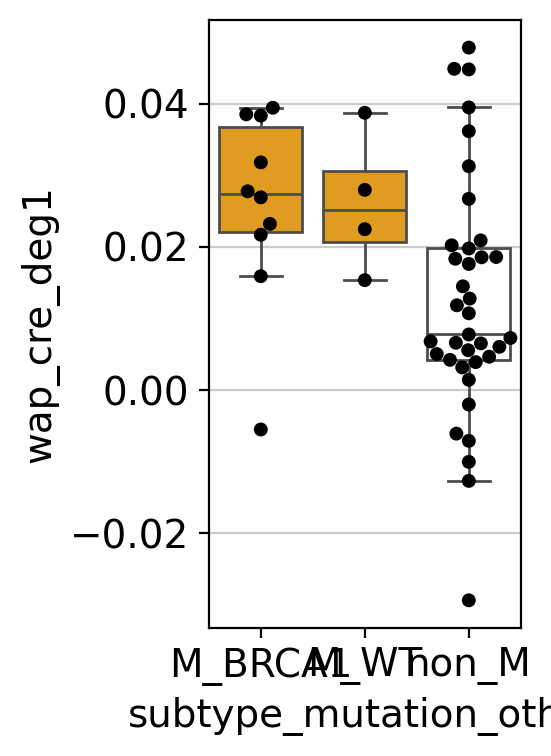

In [71]:
fig, ax = plt.subplots(figsize=(2, 4))

df=adata.obs

ax = sns.boxplot(x='subtype_mutation_other', y='wap_cre_deg1', data=df, 
                 showfliers=False,palette=['orange','orange','white']) # Hide default outliers

# 3. Overlay the swarm plot (or stripplot) to show colored points
# The 'hue' argument automatically colors points by category
sns.swarmplot(x='subtype_mutation_other', y='wap_cre_deg1', data=df, hue='subtype_mutation_other', ax=ax, 
              palette=['black','black','black'], marker='o', s=5)
        
plt.savefig('fig2_wap_barplots.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1654178/2232085857.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='subtype_mutation_other', y='tcga1', data=df,


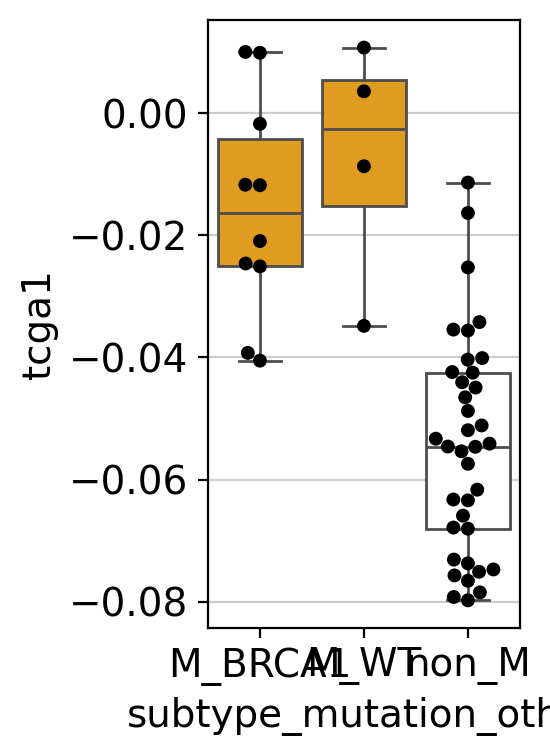

In [72]:
fig, ax = plt.subplots(figsize=(2, 4))

df=adata.obs

ax = sns.boxplot(x='subtype_mutation_other', y='tcga1', data=df, 
                 showfliers=False,palette=['orange','orange','white']) # Hide default outliers

# 3. Overlay the swarm plot (or stripplot) to show colored points
# The 'hue' argument automatically colors points by category
sns.swarmplot(x='subtype_mutation_other', y='tcga1', data=df, hue='subtype_mutation_other', ax=ax, 
              palette=['black','black','black'], marker='o', s=5)
        
plt.savefig('fig2_tnbc_M_barplots.pdf', bbox_inches='tight')
plt.show()

In [19]:
adata.obs['subtype_mutation_other'].value_counts()

subtype_mutation_other
non_M      37
M_BRCA1    10
M_WT        4
Name: count, dtype: int64

In [17]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# TCGA_M

In [85]:
f_stat, p_val = stats.f_oneway(
    adata.obs[adata.obs['subtype_mutation_other'] == 'non_M']['tcga1'],
    adata.obs[adata.obs['subtype_mutation_other'] == 'M_BRCA1']['tcga1'],
    adata.obs[adata.obs['subtype_mutation_other'] == 'M_WT']['tcga1']
)

In [86]:
print(f"ANOVA P-value: {p_val}")

ANOVA P-value: 1.2575786020862563e-08


In [87]:
tukey = pairwise_tukeyhsd(endog=adata.obs['tcga1'], groups=adata.obs['subtype_mutation_other'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
M_BRCA1   M_WT   0.0083 0.7172 -0.0174  0.0339  False
M_BRCA1  non_M  -0.0389    0.0 -0.0544 -0.0235   True
   M_WT  non_M  -0.0472    0.0   -0.07 -0.0244   True
-----------------------------------------------------


In [88]:
import pingouin as pg

In [89]:
# 1. One-way ANOVA
aov = pg.anova(dv='tcga1', between='subtype_mutation_other', data=adata.obs, detailed=True)
print(aov)

# 2. Post-hoc Tukey
posthoc = pg.pairwise_tukey(dv='tcga1', between='subtype_mutation_other', data=adata.obs)
print(posthoc)

                   Source        SS  DF        MS          F         p_unc  \
0  subtype_mutation_other  0.017500   2  0.008750  27.215012  1.257579e-08   
1                  Within  0.015432  48  0.000322        NaN           NaN   

        np2  
0  0.531387  
1       NaN  
         A      B    mean_A    mean_B      diff        se         T  \
0  M_BRCA1   M_WT -0.015602 -0.007330 -0.008271  0.010608 -0.779748   
1  M_BRCA1  non_M -0.015602 -0.054514  0.038913  0.006391  6.089000   
2     M_WT  non_M -0.007330 -0.054514  0.047184  0.009438  4.999636   

        p_tukey    hedges  
0  7.171579e-01 -0.418494  
1  5.451476e-07  2.151554  
2  2.377456e-05  2.581841  


/tmp/ipykernel_1418510/1140666081.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=adata.obs, x='subtype_mutation_other', y='tcga1',showfliers=False,palette=['orange','orange','white'])
/home/jovyan/.local/lib/python3.10/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M_BRCA1 vs. M_WT: Custom statistical test, P_val:7.172e-01
M_WT vs. non_M: Custom statistical test, P_val:2.377e-05
M_BRCA1 vs. non_M: Custom statistical test, P_val:5.451e-07


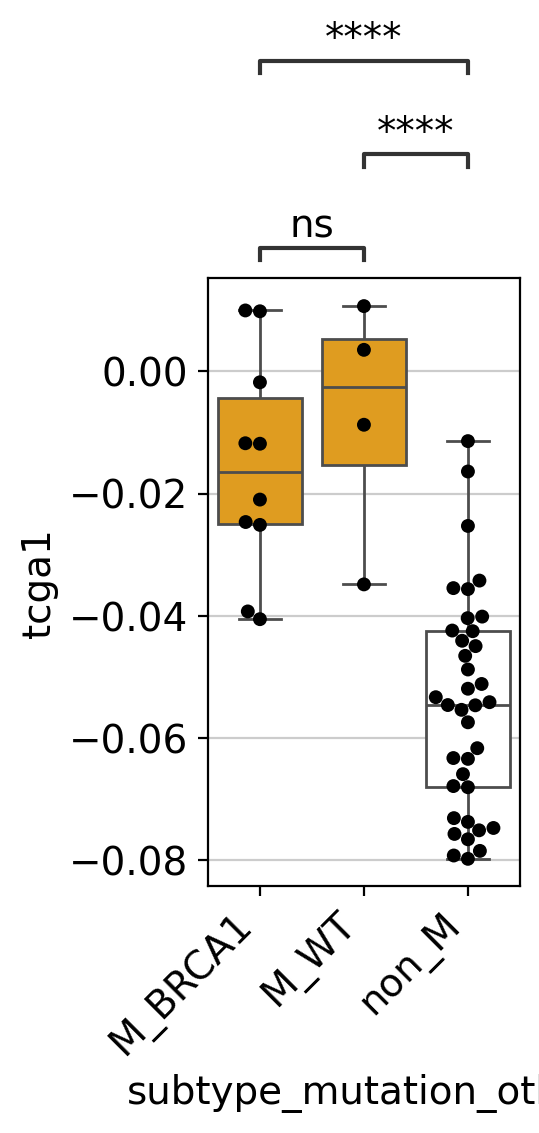

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fig, ax = plt.subplots(figsize=(2, 4))


p_values = [7.171579e-01, 5.451476e-07, 2.377456e-05]
pairs = [("M_BRCA1", "M_WT"), ("M_BRCA1", "non_M"), ("M_WT", "non_M")]


ax = sns.boxplot(data=adata.obs, x='subtype_mutation_other', y='tcga1',showfliers=False,palette=['orange','orange','white'])
sns.swarmplot(x='subtype_mutation_other', y='tcga1', data=adata.obs, hue='subtype_mutation_other', ax=ax, 
              palette=['black','black','black'], marker='o', s=5)
plt.xticks(rotation=45, ha='right')

# Add annotations
annotator = Annotator(ax, pairs, data=adata.obs, x='subtype_mutation_other', y='tcga1')
annotator.set_pvalues(p_values)
annotator.configure(text_format='star', loc='outside')
annotator.annotate()

plt.savefig('fig2_tnbc_M_anova_barplots.pdf', bbox_inches='tight')
plt.show()

# WAP

In [91]:
f_stat, p_val = stats.f_oneway(
    adata.obs[adata.obs['subtype_mutation_other'] == 'non_M']['wap_cre_deg1'],
    adata.obs[adata.obs['subtype_mutation_other'] == 'M_BRCA1']['wap_cre_deg1'],
    adata.obs[adata.obs['subtype_mutation_other'] == 'M_WT']['wap_cre_deg1']
)

In [92]:
print(f"ANOVA P-value: {p_val}")

ANOVA P-value: 0.031031537434416192


In [93]:
tukey = pairwise_tukeyhsd(endog=adata.obs['wap_cre_deg1'], groups=adata.obs['subtype_mutation_other'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
M_BRCA1   M_WT   0.0003 0.9993 -0.0223 0.0229  False
M_BRCA1  non_M  -0.0135 0.0534 -0.0271 0.0002  False
   M_WT  non_M  -0.0138 0.2321 -0.0339 0.0063  False
----------------------------------------------------


In [94]:
# 1. One-way ANOVA
aov = pg.anova(dv='wap_cre_deg1', between='subtype_mutation_other', data=adata.obs, detailed=True)
print(aov)

# 2. Post-hoc Tukey
posthoc = pg.pairwise_tukey(dv='wap_cre_deg1', between='subtype_mutation_other', data=adata.obs)
print(posthoc)

                   Source        SS  DF        MS         F     p_unc  \
0  subtype_mutation_other  0.001866   2  0.000933  3.736571  0.031032   
1                  Within  0.011983  48  0.000250       NaN       NaN   

        np2  
0  0.134716  
1       NaN  
         A      B    mean_A    mean_B      diff        se         T   p_tukey  \
0  M_BRCA1   M_WT  0.025798  0.026120 -0.000322  0.009348 -0.034423  0.999347   
1  M_BRCA1  non_M  0.025798  0.012338  0.013460  0.005631  2.390194  0.053360   
2     M_WT  non_M  0.026120  0.012338  0.013782  0.008316  1.657219  0.232122   

     hedges  
0 -0.023705  
1  0.821054  
2  0.830153  


/tmp/ipykernel_1418510/2278165005.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=adata.obs, x='subtype_mutation_other', y='wap_cre_deg1',showfliers=False,palette=['orange','orange','white'])
/home/jovyan/.local/lib/python3.10/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M_BRCA1 vs. M_WT: Custom statistical test, P_val:9.993e-01
M_WT vs. non_M: Custom statistical test, P_val:2.321e-01
M_BRCA1 vs. non_M: Custom statistical test, P_val:5.336e-02


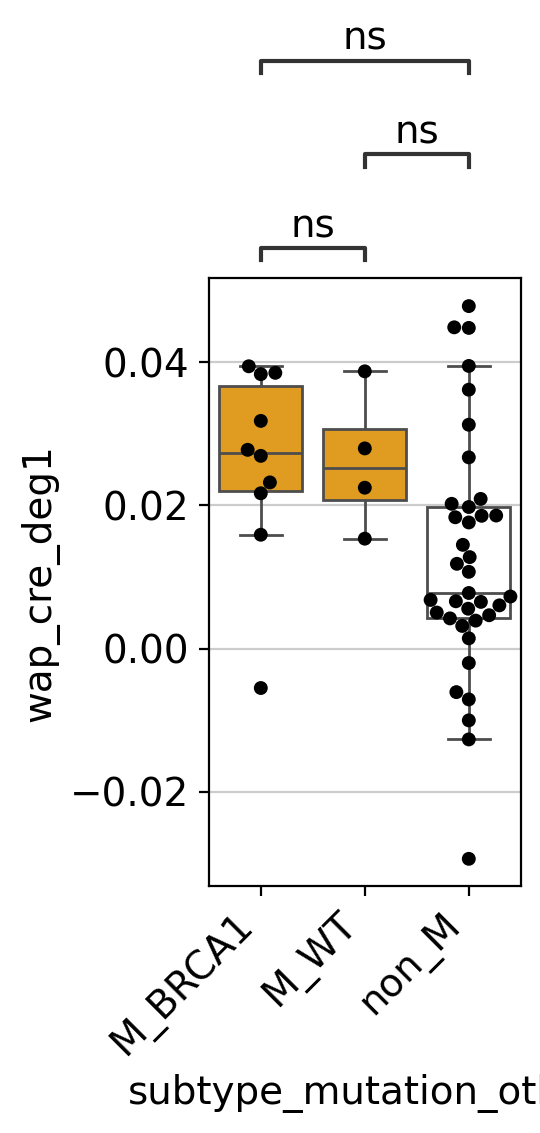

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fig, ax = plt.subplots(figsize=(2, 4))


p_values = [0.999347, 0.053360, 0.232122]
pairs = [("M_BRCA1", "M_WT"), ("M_BRCA1", "non_M"), ("M_WT", "non_M")]


ax = sns.boxplot(data=adata.obs, x='subtype_mutation_other', y='wap_cre_deg1',showfliers=False,palette=['orange','orange','white'])
sns.swarmplot(x='subtype_mutation_other', y='wap_cre_deg1', data=adata.obs, hue='subtype_mutation_other', ax=ax, 
              palette=['black','black','black'], marker='o', s=5)
plt.xticks(rotation=45, ha='right')

# Add annotations
annotator = Annotator(ax, pairs, data=adata.obs, x='subtype_mutation_other', y='wap_cre_deg1')
annotator.set_pvalues(p_values)
annotator.configure(text_format='star', loc='outside')
annotator.annotate()

plt.savefig('fig2_wap_anova_barplots.pdf', bbox_inches='tight')
plt.show()

# Blg

In [96]:
f_stat, p_val = stats.f_oneway(
    adata.obs[adata.obs['subtype_mutation_other'] == 'non_M']['blg_cre_deg1'],
    adata.obs[adata.obs['subtype_mutation_other'] == 'M_BRCA1']['blg_cre_deg1'],
    adata.obs[adata.obs['subtype_mutation_other'] == 'M_WT']['blg_cre_deg1']
)

In [97]:
print(f"ANOVA P-value: {p_val}")

ANOVA P-value: 0.03237008912209259


In [98]:
tukey = pairwise_tukeyhsd(endog=adata.obs['blg_cre_deg1'], groups=adata.obs['subtype_mutation_other'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
M_BRCA1   M_WT  -0.0135 0.5121 -0.0429 0.0159  False
M_BRCA1  non_M   0.0121  0.233 -0.0056 0.0298  False
   M_WT  non_M   0.0256  0.056 -0.0005 0.0517  False
----------------------------------------------------


In [99]:
# 1. One-way ANOVA
aov = pg.anova(dv='blg_cre_deg1', between='subtype_mutation_other', data=adata.obs, detailed=True)
print(aov)

# 2. Post-hoc Tukey
posthoc = pg.pairwise_tukey(dv='blg_cre_deg1', between='subtype_mutation_other', data=adata.obs)
print(posthoc)

                   Source        SS  DF        MS         F    p_unc       np2
0  subtype_mutation_other  0.003106   2  0.001553  3.687808  0.03237  0.133192
1                  Within  0.020215  48  0.000421       NaN      NaN       NaN
         A      B    mean_A    mean_B      diff        se         T   p_tukey  \
0  M_BRCA1   M_WT  0.051360  0.037872  0.013488  0.012141  1.110939  0.512090   
1  M_BRCA1  non_M  0.051360  0.063464 -0.012104  0.007314 -1.654884  0.233045   
2     M_WT  non_M  0.037872  0.063464 -0.025592  0.010801 -2.369325  0.055962   

     hedges  
0  0.620174  
1 -0.576321  
2 -1.228872  


/tmp/ipykernel_1418510/1249624435.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=adata.obs, x='subtype_mutation_other', y='blg_cre_deg1',showfliers=False,palette=['orange','orange','white'])
/home/jovyan/.local/lib/python3.10/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M_BRCA1 vs. M_WT: Custom statistical test, P_val:5.121e-01
M_WT vs. non_M: Custom statistical test, P_val:5.596e-02
M_BRCA1 vs. non_M: Custom statistical test, P_val:2.330e-01


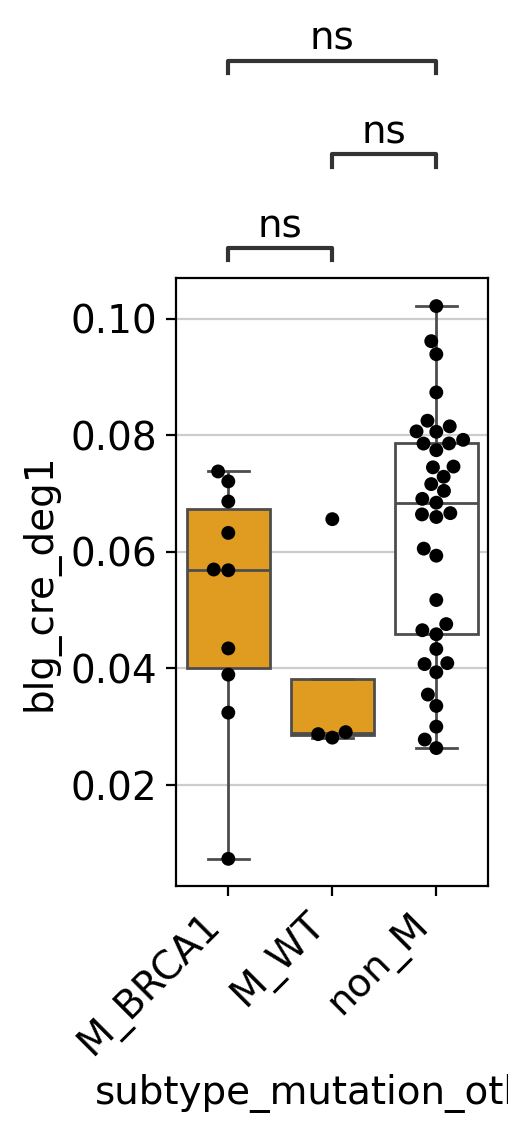

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fig, ax = plt.subplots(figsize=(2, 4))


p_values = [0.512090, 0.233045, 0.055962]
pairs = [("M_BRCA1", "M_WT"), ("M_BRCA1", "non_M"), ("M_WT", "non_M")]


ax = sns.boxplot(data=adata.obs, x='subtype_mutation_other', y='blg_cre_deg1',showfliers=False,palette=['orange','orange','white'])
sns.swarmplot(x='subtype_mutation_other', y='blg_cre_deg1', data=adata.obs, hue='subtype_mutation_other', ax=ax, 
              palette=['black','black','black'], marker='o', s=5)
plt.xticks(rotation=45, ha='right')

# Add annotations
annotator = Annotator(ax, pairs, data=adata.obs, x='subtype_mutation_other', y='blg_cre_deg1')
annotator.set_pvalues(p_values)
annotator.configure(text_format='star', loc='outside')
annotator.annotate()

plt.savefig('fig2_blg_anova_barplots.pdf', bbox_inches='tight')
plt.show()

# test

In [101]:
f_stat, p_val = stats.f_oneway(
    adata.obs[adata.obs['subtype_M_or_other'] == 'TNBC_other']['wap_cre_deg1'],
    adata.obs[adata.obs['subtype_M_or_other'] == 'TNBC_M']['wap_cre_deg1']
)

In [102]:
print(f"ANOVA P-value: {p_val}")

ANOVA P-value: 0.0080698882358848


In [103]:
tukey = pairwise_tukeyhsd(endog=adata.obs['wap_cre_deg1'], groups=adata.obs['subtype_M_or_other'], alpha=0.05)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1   group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------
TNBC_M TNBC_other  -0.0136 0.0081 -0.0234 -0.0037   True
--------------------------------------------------------


In [104]:
# 1. One-way ANOVA
aov = pg.anova(dv='wap_cre_deg1', between='subtype_M_or_other', data=adata.obs, detailed=True)
print(aov)

# 2. Post-hoc Tukey
posthoc = pg.pairwise_tukey(dv='wap_cre_deg1', between='subtype_M_or_other', data=adata.obs)
print(posthoc)

               Source        SS  DF        MS         F    p_unc       np2
0  subtype_M_or_other  0.001865   1  0.001865  7.627435  0.00807  0.134695
1              Within  0.011984  49  0.000245       NaN      NaN       NaN
        A           B   mean_A    mean_B      diff        se         T  \
0  TNBC_M  TNBC_other  0.02589  0.012338  0.013552  0.004907  2.761781   

   p_tukey   hedges  
0  0.00807  0.85325  


/tmp/ipykernel_1418510/1172452854.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=adata.obs, x='subtype_M_or_other', y='wap_cre_deg1',showfliers=False,palette=['orange','white'])
/home/jovyan/.local/lib/python3.10/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

TNBC_M vs. TNBC_other: Custom statistical test, P_val:8.070e-03


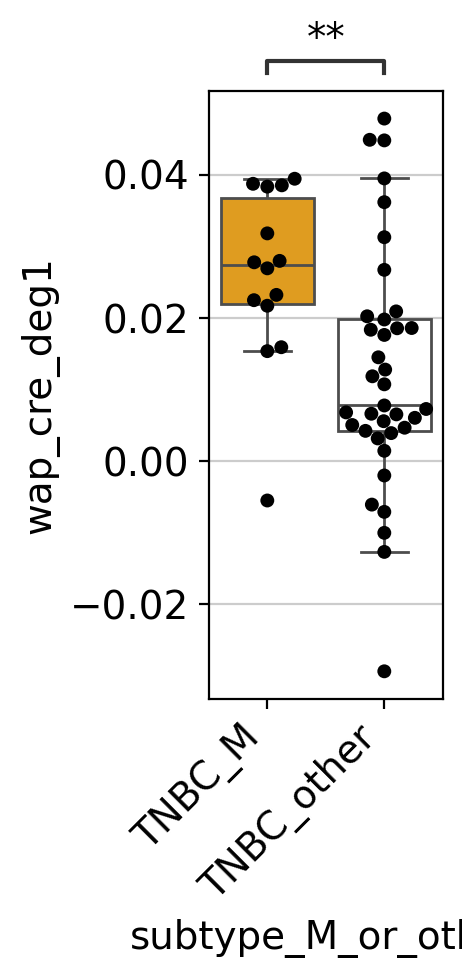

In [105]:
fig, ax = plt.subplots(figsize=(1.5, 4))


p_values = [0.00807]
pairs = [("TNBC_M", "TNBC_other")]


ax = sns.boxplot(data=adata.obs, x='subtype_M_or_other', y='wap_cre_deg1',showfliers=False,palette=['orange','white'])
sns.swarmplot(x='subtype_M_or_other', y='wap_cre_deg1', data=adata.obs, hue='subtype_M_or_other', ax=ax, 
              palette=['black','black'], marker='o', s=5)
plt.xticks(rotation=45, ha='right')

# Add annotations
annotator = Annotator(ax, pairs, data=adata.obs, x='subtype_M_or_other', y='wap_cre_deg1')
annotator.set_pvalues(p_values)
annotator.configure(text_format='star', loc='outside')
annotator.annotate()

plt.savefig('fig2_wap_barplots.pdf', bbox_inches='tight')
plt.show()

In [106]:
f_stat, p_val = stats.f_oneway(
    adata.obs[adata.obs['subtype_M_or_other'] == 'TNBC_other']['blg_cre_deg1'],
    adata.obs[adata.obs['subtype_M_or_other'] == 'TNBC_M']['blg_cre_deg1']
)

In [107]:
print(f"ANOVA P-value: {p_val}")

ANOVA P-value: 0.01694453825153094


In [108]:
tukey = pairwise_tukeyhsd(endog=adata.obs['blg_cre_deg1'], groups=adata.obs['subtype_M_or_other'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1   group2   meandiff p-adj  lower upper  reject
-----------------------------------------------------
TNBC_M TNBC_other    0.016 0.0169 0.003 0.0289   True
-----------------------------------------------------


In [109]:
# 1. One-way ANOVA
aov = pg.anova(dv='blg_cre_deg1', between='subtype_M_or_other', data=adata.obs, detailed=True)
print(aov)

# 2. Post-hoc Tukey
posthoc = pg.pairwise_tukey(dv='blg_cre_deg1', between='subtype_M_or_other', data=adata.obs)
print(posthoc)

               Source        SS  DF        MS         F     p_unc       np2
0  subtype_M_or_other  0.002586   1  0.002586  6.112219  0.016945  0.110905
1              Within  0.020734  49  0.000423       NaN       NaN       NaN
        A           B    mean_A    mean_B      diff        se        T  \
0  TNBC_M  TNBC_other  0.047506  0.063464 -0.015958  0.006455 -2.47229   

    p_tukey    hedges  
0  0.016945 -0.763812  


/tmp/ipykernel_1418510/3894263377.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=adata.obs, x='subtype_M_or_other', y='blg_cre_deg1',showfliers=False,palette=['orange','white'])
/home/jovyan/.local/lib/python3.10/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

TNBC_M vs. TNBC_other: Custom statistical test, P_val:1.695e-02


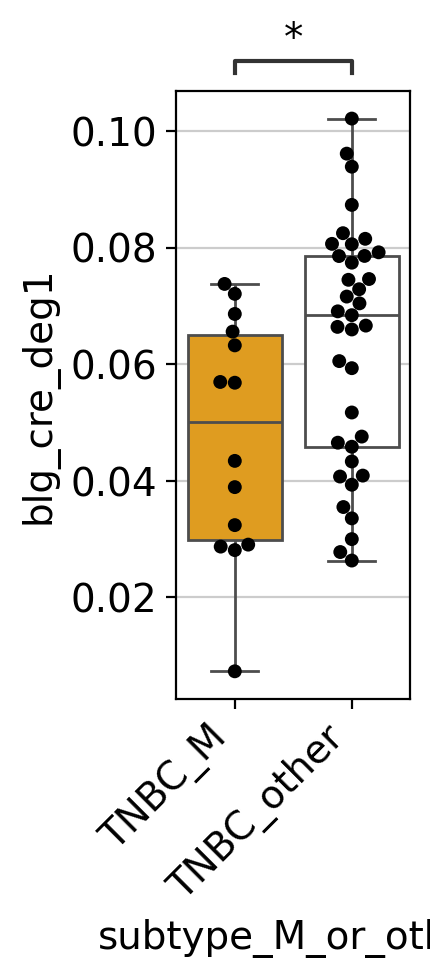

In [110]:
fig, ax = plt.subplots(figsize=(1.5, 4))


p_values = [0.016945]
pairs = [("TNBC_M", "TNBC_other")]


ax = sns.boxplot(data=adata.obs, x='subtype_M_or_other', y='blg_cre_deg1',showfliers=False,palette=['orange','white'])
sns.swarmplot(x='subtype_M_or_other', y='blg_cre_deg1', data=adata.obs, hue='subtype_M_or_other', ax=ax, 
              palette=['black','black'], marker='o', s=5)
plt.xticks(rotation=45, ha='right')

# Add annotations
annotator = Annotator(ax, pairs, data=adata.obs, x='subtype_M_or_other', y='blg_cre_deg1')
annotator.set_pvalues(p_values)
annotator.configure(text_format='star', loc='outside')
annotator.annotate()

plt.savefig('fig2_blg_barplots.pdf', bbox_inches='tight')
plt.show()